<a href="https://colab.research.google.com/github/deepakk7195/IISC_CDS_DS/blob/Neural_Networks/MiniProject_3_Video_Classification_Priyanka_V10_Stan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Program in Computational Data Science

##  A program by IISc and TalentSprint

### Mini Project Notebook: Video based Action Classification using LSTM

## Learning Objectives

At the end of the experiment, you will be able to :

* extract frames out of a video
* build the CNN model to extract features from the video frames
* train LSTM/GRU model to perform action classification

## Information

**Background:** The CNN LSTM architecture involves using Convolutional Neural Network (CNN) layers for feature extraction on input data combined with LSTMs to support sequence prediction.

CNN LSTMs were developed for visual time series prediction problems and the application of generating textual descriptions from sequences of images (e.g. videos). Specifically, the problems of:



*   Activity Recognition: Generating a textual description of an activity demonstrated in a sequence of images
*   Image Description: Generating a textual description of a single image.
*   Video Description: Generating a textual description of a sequence of images.

**Applications:** Applications such as surveillance, video retrieval and
human-computer interaction require methods for recognizing human actions in various scenarios. In the area of robotics, the tasks of
autonomous navigation or social interaction could also take advantage of the knowledge extracted
from live video recordings. Typical scenarios
include scenes with cluttered, moving backgrounds, nonstationary camera, scale variations, individual variations in
appearance and cloth of people, changes in light and view
point and so forth. All of these conditions introduce challenging problems that can be addressed using deep learning (computer vision) models.

## Dataset



**Dataset:** This dataset consists of labelled videos of 6 human actions (walking, jogging, running, boxing, hand waving and hand clapping) performed several times by 25 subjects in four different scenarios: outdoors s1, outdoors with scale variation s2, outdoors with different clothes s3 and indoors s4 as illustrated below.

![img](https://cdn.iisc.talentsprint.com/CDS/Images/actions.gif)

All sequences were taken over homogeneous backgrounds with a static camera with 25fps frame rate. The sequences were downsampled to the spatial resolution of 160x120 pixels and have a length of four seconds in average. In summary, there are 25x6x4=600 video files for each combination of 25 subjects, 6 actions and 4 scenarios. For this mini-project we have randomly selected 20% of the data as test set.

Dataset source: https://www.csc.kth.se/cvap/actions/

**Methodology:**

When performing image classification, we input an image to our CNN; Obtain the predictions from the CNN;
Choose the label with the largest corresponding probability


Since a video is just a series of image frames, in a video classification, we Loop over all frames in the video file;
For each frame, pass the frame through the CNN; Classify each frame individually and independently of each other; Choose the label with the largest corresponding probability;
Label the frame and write the output frame to disk

Refer this [Video Classification using Keras](https://medium.com/video-classification-using-keras-and-tensorflow/action-recognition-and-video-classification-using-keras-and-tensorflow-56badcbe5f77) for complete understanding and implementation example of video classification.

## Problem Statement

Train a CNN-LSTM based deep neural net to recognize the action being performed in a video

## Grading = 10 Points

### Install and re-start the runtime

In [ ]:
!pip3 install imageio==2.4.1

In [ ]:
#@title Download Dataset
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Actions.zip
!unzip -qq Actions.zip
print("Dataset downloaded successfully!!")

replace Actions/train/Walking/person01_walking_d1_uncomp.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A
A
Dataset downloaded successfully!!


### Import required packages

In [ ]:
import keras
from keras import applications
from keras import optimizers
from keras.models import Sequential, Model
from keras.layers import *
from keras.applications.vgg16 import VGG16
from keras.models import Model
from keras.layers import Dense, Input
#from keras.layers.pooling import GlobalAveragePooling2D
from keras.layers import GlobalAveragePooling2D # Import directly from keras.layers
from keras.layers import LSTM
from keras.layers import TimeDistributed
from keras.layers import Conv2D, BatchNormalization, MaxPool2D, GlobalMaxPool2D,Flatten
from keras.layers import GRU, Dense, Dropout
from keras.layers import Conv2D, BatchNormalization, MaxPool2D, GlobalMaxPool2D
from tensorflow.keras.optimizers import Adam
import math
import os, glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import imageio

### Load the data and generate frames of video (2 points)

Detecting an action is possible by analyzing a series of images (that we name “frames”) that are taken in time.

Hint: Refer data preparation section in [keras_video_classification](https://keras.io/examples/vision/video_classification/)


In [ ]:
train_data_dir = "/content/Actions/train/"
test_data_dir = "/content/Actions/test/"


In [ ]:
from itertools import count
def crop_center_square(frame):
    y, x = frame.shape[0:2]
    min_dim = min(y, x)
    start_x = (x // 2) - (min_dim // 2)
    start_y = (y // 2) - (min_dim // 2)
    return frame[start_y : start_y + min_dim, start_x : start_x + min_dim]

IMG_SIZE = 224

##collecting starting frames
def load_video(path, max_frames=0, resize=(IMG_SIZE, IMG_SIZE)):
    cap = cv2.VideoCapture(path)
    frames = []
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = crop_center_square(frame)
            frame = cv2.resize(frame, resize)
            frame = frame[:, :, [2, 1, 0]]
            frames.append(frame)

            if len(frames) == max_frames:
                break
    finally:
        cap.release()
    return np.array(frames)

In [ ]:
def load_video_offset(path, max_frames=0, resize=(IMG_SIZE, IMG_SIZE)):
    cap = cv2.VideoCapture(path)
    offset =30
    count=0
    frames = []
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if (count >offset):
               frame = crop_center_square(frame)
               frame = cv2.resize(frame, resize)
               frame = frame[:, :, [2, 1, 0]]
               frames.append(frame)
            count+=1

            if len(frames) == max_frames:
                break
    finally:
        cap.release()
    return np.array(frames)

In [ ]:
#time step
def detect_defects(video_path, threshold):
  cap = cv2.VideoCapture(video_path)
  defect_frames = []

  if not cap.isOpened():
      print("Error opening video")
      return []

  while True:
      ret, frame = cap.read()
      if not ret:
          break

      # Convert to grayscale for simpler analysis
      gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

      # Calculate average pixel intensity
      avg_intensity = cv2.mean(gray_frame)[0]

      # Check for significant deviation from average
      if abs(avg_intensity - threshold) > 50:
          defect_frames.append(cap.get(cv2.CAP_PROP_POS_FRAMES) - 1)

  cap.release()
  return defect_frames

# Example usage (adjust threshold as needed)
video_path = "path/to/your/video.mp4"
defect_frames = detect_defects(video_path, 100)

if defect_frames:
  print(f"Potential defect frames: {defect_frames}")
else:
  print("No significant brightness defects detected.")

Error opening video
No significant brightness defects detected.


In [ ]:

def load_video_with_skipframe(path, max_frames=0, resize=(IMG_SIZE, IMG_SIZE)):
    cap = cv2.VideoCapture(path)
    # Check if video is opened successfully if not cap.isOpened(): print("Error opening video") exit()
    # Get the frame count
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    # Get the FPS (Frames Per Second)
    fps = cap.get(cv2.CAP_PROP_FPS)
    # Calculate the video duration in seconds
    duration = frame_count / fps
    frame_step=int(frame_count/max_frames)
    print(f"Frame step = {frame_step}")
    #d=0
    count = 0
    frames = []
    try:
        while (len(frames) < max_frames):
            success, frame = cap.read()
            # if not success:
            #     break
            #if success and (count+1)%frame_step==0:
            frame = crop_center_square(frame)
            frame = cv2.resize(frame, resize)
            frame = frame[:, :, [2, 1, 0]]
            frames.append(frame)
            count+=1
            #frames.append(frame)

            # if len(frames) == max_frames:
            #     break
    finally:
        cap.release()

    print(f"Number of frame extracted = {len(frames)}")

    return np.array(frames)

In [ ]:
def extract_frames(folder_dir,max_frames,imgshape): # 'folder_dir' is now a parameter
    # Initialize an empty list to store video file names
    video_files = []
    labels = []
    # Iterate through all files in the directory
    for label in os.listdir(folder_dir):
        for filename in os.listdir(os.path.join(folder_dir,label)):
            # # Add the file name to the list
            # video_files.append(filename)
            path= os.path.join(folder_dir,label,filename)
            # print(path)
            # load= load_video(path,max_frames=max_frames,resize=imgshape)   #Stan June 30
            load= load_video_with_skipframe(path,max_frames=max_frames,resize=imgshape)
            #print(load.shape)
            # print(load.shape)
            video_files.append(load)
            labels.append(label)
    return video_files,labels


In [ ]:
train_data,train_label=extract_frames(train_data_dir,25,(224,224))
len(train_data)

Frame step = 14
Number of frame extracted = 25
Frame step = 15
Number of frame extracted = 25
Frame step = 24
Number of frame extracted = 25
Frame step = 18
Number of frame extracted = 25
Frame step = 18
Number of frame extracted = 25
Frame step = 18
Number of frame extracted = 25
Frame step = 18
Number of frame extracted = 25
Frame step = 21
Number of frame extracted = 25
Frame step = 16
Number of frame extracted = 25
Frame step = 19
Number of frame extracted = 25
Frame step = 19
Number of frame extracted = 25
Frame step = 20
Number of frame extracted = 25
Frame step = 15
Number of frame extracted = 25
Frame step = 14
Number of frame extracted = 25
Frame step = 11
Number of frame extracted = 25
Frame step = 19
Number of frame extracted = 25
Frame step = 16
Number of frame extracted = 25
Frame step = 19
Number of frame extracted = 25
Frame step = 18
Number of frame extracted = 25
Frame step = 15
Number of frame extracted = 25
Frame step = 14
Number of frame extracted = 25
Frame step = 

479

In [ ]:
train_data[0].shape

(25, 224, 224, 3)

In [ ]:
test_data,test_label=extract_frames(test_data_dir,25,(224,224))
test_data[0].shape

Frame step = 18
Number of frame extracted = 25
Frame step = 14
Number of frame extracted = 25
Frame step = 22
Number of frame extracted = 25
Frame step = 17
Number of frame extracted = 25
Frame step = 21
Number of frame extracted = 25
Frame step = 16
Number of frame extracted = 25
Frame step = 24
Number of frame extracted = 25
Frame step = 17
Number of frame extracted = 25
Frame step = 16
Number of frame extracted = 25
Frame step = 18
Number of frame extracted = 25
Frame step = 17
Number of frame extracted = 25
Frame step = 10
Number of frame extracted = 25
Frame step = 17
Number of frame extracted = 25
Frame step = 16
Number of frame extracted = 25
Frame step = 17
Number of frame extracted = 25
Frame step = 20
Number of frame extracted = 25
Frame step = 16
Number of frame extracted = 25
Frame step = 20
Number of frame extracted = 25
Frame step = 18
Number of frame extracted = 25
Frame step = 22
Number of frame extracted = 25
Frame step = 16
Number of frame extracted = 25
Frame step = 

(25, 224, 224, 3)

In [ ]:
from IPython.display import Video

Video("/content/Actions/train/Walking/person01_walking_d1_uncomp.avi")


In [ ]:
from moviepy.editor import *
path="/content/Actions/train/running/person01_running_d1_uncomp.avi"
clip=VideoFileClip(path)
ipython_display(clip,width=280)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


#### Visualize the frames and analyze the object in each frame. (1 point)

* Plot the frames of each class per row (6 rows)
* Plot the title as label on each subplot

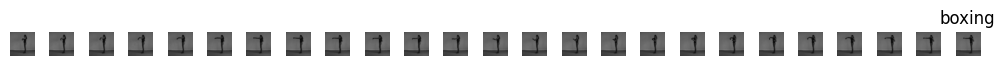

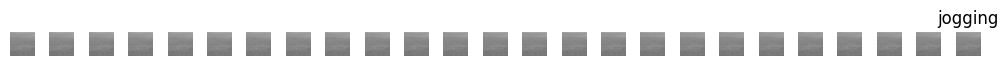

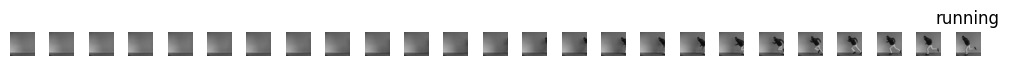

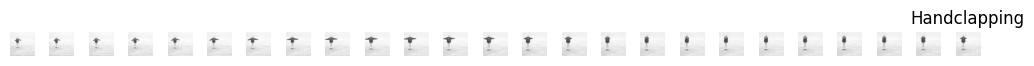

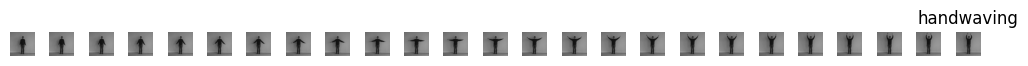

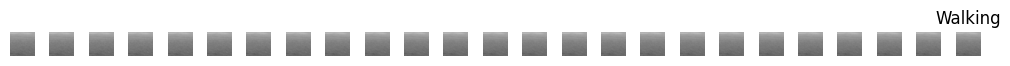

In [ ]:
def plot_frames(frames,label):
    num_frames = len(frames)
    fig, axes = plt.subplots(1, num_frames, figsize=(10, 5))  # Adjust figsize as needed

    for i, frame in enumerate(frames):
        axes[i].imshow(frame)  # Assuming frames are in numpy array format
        axes[i].axis('off')

    plt.tight_layout()
    plt.title(label)
    plt.show()

for i in range(6):
    plot_frames(train_data[i*80], train_label[i*80])

#plot_frames(train_data[320], train_label[320])

In [ ]:
from sklearn.preprocessing import LabelEncoder
def convert_labels_to_integers(string_labels):
    """
    Convert a list of string labels into integer labels using LabelEncoder.

    Parameters:
    - string_labels: A list of string labels.

    Returns:
    - A list of integer labels.
    """
    # Initialize LabelEncoder
    label_encoder = LabelEncoder()

    # Fit LabelEncoder with string labels and transform them to integers
    integer_labels = label_encoder.fit_transform(string_labels)

    return integer_labels

In [ ]:
train_int_labels=convert_labels_to_integers(train_label)


In [ ]:
test_int_labels=convert_labels_to_integers(test_label)

In [ ]:
def one_hot_encode(labels, num_classes):
    """
    Perform one-hot encoding on labels.

    Parameters:
    - labels: A list or numpy array containing integer labels.
    - num_classes: Total number of classes (unique labels).

    Returns:
    - A numpy array of shape (len(labels), num_classes) with one-hot encoded labels.
    """
    # Initialize an array of zeros with shape (number of labels, number of classes)
    encoded_labels = np.zeros((len(labels), num_classes))

    # Set the appropriate elements to 1 based on the label value
    for i, label in enumerate(labels):
        encoded_labels[i, label] = 1

    return encoded_labels

In [ ]:
num_classes = 6
train_labels_encoded = one_hot_encode(train_int_labels, num_classes)
test_labels_encoded = one_hot_encode(test_int_labels, num_classes)

In [ ]:
train_data=np.array(train_data)
train_labels_encoded=np.array(train_labels_encoded)
test_data=np.array(test_data)
test_labels_encoded = np.array(test_labels_encoded)

In [ ]:
train_labels_encoded.shape

(479, 6)

In [ ]:
train_data.shape

(479, 25, 224, 224, 3)

In [ ]:
test_data.shape

(120, 25, 224, 224, 3)

In [ ]:
len(test_data)

120

In [ ]:
len(test_labels_encoded)

120

In [ ]:
#train_data_new=train_data.reshape((479,50,224,224,3))
#print(len(train_data_new))

In [ ]:
type(train_labels_encoded)

numpy.ndarray

In [ ]:
print(len(train_data))
print(len(train_labels_encoded))

479
479


### Create the Neural Network (4 points)

We can build the model in several ways. We can use a well-known model that we inject in time distributed layer, or we can build our own.

With custom ConvNet each input image of the sequence must pass to a convolutional network. The goal is to train that model for each frame and then decide the class to infer.

* Use ConvNet and Time distributed to detect features.
* Inject the Time distributed output to GRU or LSTM to treat as a time series.
* Apply a DenseNet to take the decision and classify.

##### Build the ConvNet for the feature extraction, GRU LSTM layers as a time series and Dense layers for classification

Below Code need to be tweaked

In [ ]:
def build_model_cnn():
   model_cnlst = models.Sequential()
   model_cnlst.add(Conv2D(128, (3, 3), strides=(2,2),activation='relu'))
   model_cnlst.add(Conv2D(64, (3, 3),  strides=(2,2),activation='relu'))
   model_cnlst.add(BatchNormalization())
   model_cnlst.add(MaxPooling2D(2,2))
   model_cnlst.add(Conv2D(64, (3, 3), strides=(2,2),activation='relu'))
   model_cnlst.add(Conv2D(32, (3, 3), strides=(2,2),activation='relu'))
   model_cnlst.add(BatchNormalization())
   model_cnlst.add(MaxPooling2D(2,2))
   return model_cnlst


In [ ]:
from keras import models
model_cnlst = models.Sequential()
convnet = build_model_cnn()
model_cnlst.add(TimeDistributed(convnet,input_shape=(25,224,224,3)))
model_cnlst.add(TimeDistributed(Flatten()))

model_cnlst.add(LSTM(64,return_sequences =True)) # used 128 units instead of 32
model_cnlst.add(GRU(32)) # used 128 units instead of 32
#model_cnlst.add(Flatten())
# model_cnlst.add(Dropout(0.2))

model_cnlst.add(Dense(64,activation='relu'))
model_cnlst.add(Dense(32,activation='relu'))
model_cnlst.add(Dropout(0.2))
model_cnlst.add(Dense(6, activation='softmax'))
model_cnlst.summary()



Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_4 (TimeDi  (None, 25, 3, 3, 32)      133152    
 stributed)                                                      
                                                                 
 time_distributed_5 (TimeDi  (None, 25, 288)           0         
 stributed)                                                      
                                                                 
 lstm_2 (LSTM)               (None, 25, 64)            90368     
                                                                 
 gru_2 (GRU)                 (None, 32)                9408      
                                                                 
 dense_6 (Dense)             (None, 64)                2112      
                                                                 
 dense_7 (Dense)             (None, 32)               

#### Setup the parameters and train the model with epochs, batch wise

* Use train data to fit the model and test data for validation
* Configure batch size and epochs
* Plot the loss of train and test data

In [ ]:
# Note: There will be a high memory requirement for the training steps below.
# You should work on a GPU/TPU based runtime. See 'Change Runtime' in Colab
# Training time for each epoch could be ~30 mins
# To save and re-load your model later, see the reference below:
# https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/keras/save_and_load.ipynb

# YOUR CODE HERE

In [ ]:
from keras import optimizers
# callbacks_list_cnlst=[keras.callbacks.EarlyStopping(
# monitor='acc',patience=3),
#                keras.callbacks.ModelCheckpoint(
#                filepath='cnn_lstm_model_new3.h5',
#                monitor='val_loss',
#                save_best_only=True),
#                 keras.callbacks.ReduceLROnPlateau(monitor = "val_loss", factor = 0.1, patience = 3)
#                ]


model_cnlst.compile(optimizer='adam',loss='categorical_crossentropy',metrics=["accuracy"])

In [ ]:
# Set the number of epochs and steps per epoch
epochs = 5

# Fit the model
history = model_cnlst.fit(
             train_data,
             train_labels_encoded,
             batch_size=1,
             epochs=epochs,
            # validation_data=(validation_dataset_new,validation_labels),
             #callbacks=callbacks
             )

Epoch 1/5
479/479 [==============================] - 15s 31ms/step - loss: 0.9588 - accuracy: 0.4990
Epoch 2/5
479/479 [==============================] - 15s 30ms/step - loss: 0.9238 - accuracy: 0.5073
Epoch 3/5
479/479 [==============================] - 15s 30ms/step - loss: 0.9023 - accuracy: 0.5720
Epoch 4/5
479/479 [==============================] - 15s 30ms/step - loss: 0.8488 - accuracy: 0.5658
Epoch 5/5
479/479 [==============================] - 15s 30ms/step - loss: 0.8132 - accuracy: 0.6284


In [ ]:
# Evaluate the model on the validation data
loss, accuracy = model_cnlst.evaluate(test_data,test_labels_encoded)

print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

4/4 [==============================] - 2s 162ms/step - loss: 1.6140 - accuracy: 0.4167
Test Loss: 1.6139723062515259
Test Accuracy: 0.4166666567325592


In [ ]:
pred_class_probs = model_cnlst.predict(test_data)
pred_class = np.argmax(pred_class_probs, axis=1)

4/4 [==============================] - 1s 125ms/step


In [ ]:
print(pred_class_probs)

[[9.17823538e-02 5.54586819e-04 8.19723547e-01 8.73877555e-02
  3.59952246e-04 1.91874962e-04]
 [2.98767895e-01 6.72944216e-03 4.39679176e-01 2.43364900e-01
  4.22862079e-03 7.22998986e-03]
 [1.41009782e-03 7.81644061e-02 2.36086478e-03 1.20373734e-03
  2.57027239e-01 6.59833729e-01]
 [1.53146252e-01 3.63217387e-03 6.73953295e-01 1.63434744e-01
  3.11915902e-03 2.71437061e-03]
 [2.91344337e-03 1.35175094e-01 5.47338324e-03 2.52420688e-03
  2.67674565e-01 5.86239278e-01]
 [4.10827398e-01 7.46464217e-03 2.13968694e-01 3.52199435e-01
  5.58387768e-03 9.95604601e-03]
 [2.55014352e-03 1.90533221e-01 4.52804891e-03 2.35837791e-03
  2.86220789e-01 5.13809383e-01]
 [4.32446063e-01 4.84534889e-04 1.87342629e-01 3.78956765e-01
  2.54364888e-04 5.15638618e-04]
 [2.82691479e-01 1.70225184e-03 4.65407759e-01 2.47972727e-01
  1.21958228e-03 1.00622023e-03]
 [1.21394843e-01 7.22242966e-02 5.80017626e-01 1.05575651e-01
  1.04846135e-01 1.59414206e-02]
 [1.74384087e-01 9.44839418e-03 6.26750350e-01 1.7

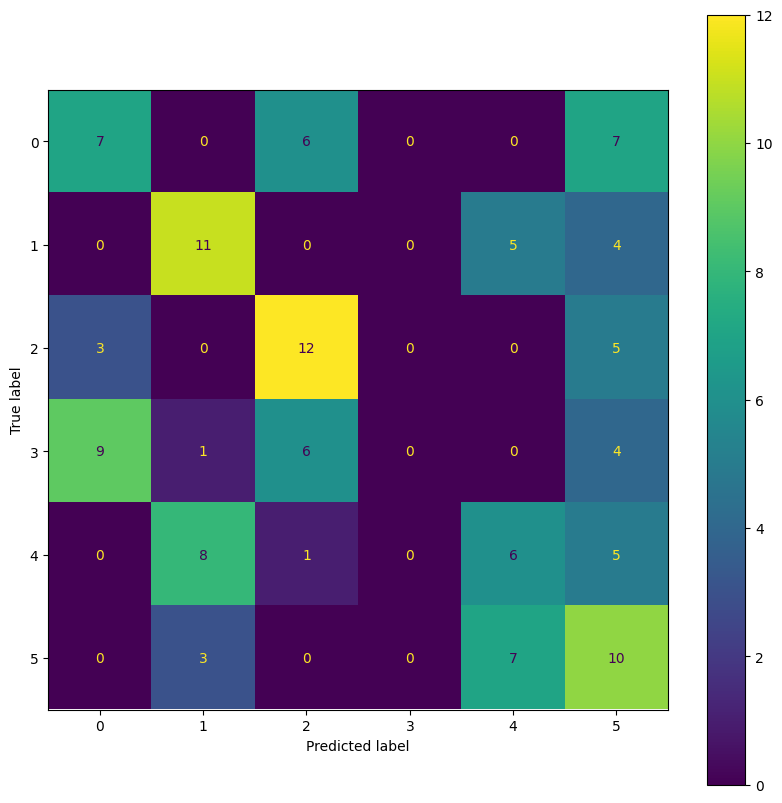

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_int_labels, pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax)
# plt.tight_layout()
plt.show()

In [ ]:
def build_model_cnn_rev():
   model_cnlst = models.Sequential()
   model_cnlst.add(Conv2D(128, (3, 3), strides=(2,2),activation='relu'))
   model_cnlst.add(BatchNormalization())
   model_cnlst.add(MaxPooling2D(2,2))
   model_cnlst.add(Conv2D(64, (3, 3), strides=(2,2),activation='relu'))
   model_cnlst.add(BatchNormalization())
   model_cnlst.add(MaxPooling2D(2,2))
   model_cnlst.add(Conv2D(32, (3, 3), strides=(2,2),activation='relu'))
   model_cnlst.add(BatchNormalization())
   model_cnlst.add(MaxPooling2D(2,2))
   return model_cnlst

In [ ]:
from keras import models
model_cnlst = models.Sequential()
convnet = build_model_cnn_rev()
model_cnlst.add(TimeDistributed(convnet,input_shape=(25,224,224,3)))
model_cnlst.add(TimeDistributed(Flatten()))

model_cnlst.add(LSTM(64,return_sequences =True)) # used 128 units instead of 32
model_cnlst.add(GRU(32)) # used 128 units instead of 32

#model_cnlst.add(Dense(1024,activation='relu'))
#model_cnlst.add(Dense(256,activation='relu'))
model_cnlst.add(Dense(64,activation='relu'))
model_cnlst.add(Dense(32,activation='relu'))
model_cnlst.add(Dropout(0.2))
model_cnlst.add(Dense(6, activation='softmax'))
model_cnlst.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_2 (TimeDi  (None, 25, 3, 3, 32)      96736     
 stributed)                                                      
                                                                 
 time_distributed_3 (TimeDi  (None, 25, 288)           0         
 stributed)                                                      
                                                                 
 lstm_1 (LSTM)               (None, 25, 64)            90368     
                                                                 
 gru_1 (GRU)                 (None, 32)                9408      
                                                                 
 dense_3 (Dense)             (None, 64)                2112      
                                                                 
 dense_4 (Dense)             (None, 32)               

In [ ]:
from keras import optimizers
model_cnlst.compile(optimizer='adam',loss='categorical_crossentropy',metrics=["accuracy"])


In [ ]:
callbacks_list = [ keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
    ),
 keras.callbacks.ModelCheckpoint(
  filepath="checkpoint_path.keras",
  monitor="val_loss",
  save_best_only=True,
 )
]

In [ ]:
# Set the number of epochs and steps per epoch
epochs = 5

# Fit the model
history = model_cnlst.fit(
             train_data,
             train_labels_encoded,
             batch_size=1,
             epochs=epochs,
            # validation_data=(validation_dataset_new,validation_labels),
             callbacks=callbacks_list
             )

Epoch 1/5
479/479 [==============================] - ETA: 0s - loss: 0.5697 - accuracy: 0.7745

479/479 [==============================] - 16s 34ms/step - loss: 0.5697 - accuracy: 0.7745
Epoch 2/5
479/479 [==============================] - ETA: 0s - loss: 0.6018 - accuracy: 0.7891

479/479 [==============================] - 16s 34ms/step - loss: 0.6018 - accuracy: 0.7891
Epoch 3/5
479/479 [==============================] - ETA: 0s - loss: 0.5775 - accuracy: 0.7850

479/479 [==============================] - 16s 33ms/step - loss: 0.5775 - accuracy: 0.7850
Epoch 4/5
479/479 [==============================] - ETA: 0s - loss: 0.4699 - accuracy: 0.8205

479/479 [==============================] - 16s 34ms/step - loss: 0.4699 - accuracy: 0.8205
Epoch 5/5
479/479 [==============================] - ETA: 0s - loss: 0.4239 - accuracy: 0.8351

479/479 [==============================] - 16s 33ms/step - loss: 0.4239 - accuracy: 0.8351


In [ ]:
# Evaluate the model on the validation data in batches
batch_size = 5  # Adjust this based on your GPU memory
num_batches = test_data.shape[0] // batch_size

loss = 0
accuracy = 0
for i in range(num_batches):
    start = i * batch_size
    end = (i + 1) * batch_size
    batch_loss, batch_accuracy = model_cnlst.evaluate(test_data[start:end], test_labels_encoded[start:end], verbose=0)
    loss += batch_loss
    accuracy += batch_accuracy

# Average the loss and accuracy over all batches
loss /= num_batches
accuracy /= num_batches

print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

### Use pre-trained model for feature extraction (3 points)

To create a deep learning network for video classification:

* Convert videos to sequences of feature vectors using a pretrained convolutional neural network, such as VGG16, to extract features from each frame.

* Train an LSTM network on the sequences to predict the video labels.

* Assemble a network that classifies videos directly by combining layers from both networks.

Hint: [VGG-16 CNN and LSTM](https://riptutorial.com/keras/example/29812/vgg-16-cnn-and-lstm-for-video-classification)

#### Load and fine-tune the pre-trained model

In [ ]:
frames = 25
channels = 3
rows = 224
columns = 224
classes = 6

In [ ]:
from keras.layers import GlobalAveragePooling2D # Import directly from keras.layers
from keras.layers import LSTM
from keras.layers import TimeDistributed
from keras.layers import Conv2D, BatchNormalization, MaxPool2D, GlobalMaxPool2D,Flatten
from keras.layers import GRU, Dense, Dropout
from keras.layers import Conv2D, BatchNormalization, MaxPool2D, GlobalMaxPool2D

In [ ]:
# Venu suggestion
from keras.applications.vgg16 import VGG16
from keras.models import Model
from keras import layers
from keras.layers import Dense, Input

#from pooling import GlobalAveragePooling2D
# from layers.recurrent import LSTM
# from keras.layers.wrappers import TimeDistributed
from keras.optimizers import Nadam

In [ ]:
video = Input(shape=(frames,
                     rows,
                     columns,
                     channels))

In [ ]:
cnn_base = VGG16(input_shape=(
                              rows,
                              columns,
                              channels),
                              weights="imagenet",
                              include_top=False)

58889256/58889256 [==============================] - 4s 0us/step


In [ ]:
cnn_out = GlobalAveragePooling2D()(cnn_base.output)
cnn = Model(inputs=cnn_base.input, outputs=cnn_out)
cnn.trainable = False

In [ ]:
video.shape

TensorShape([None, 25, 224, 224, 3])

In [ ]:
encoded_frames = TimeDistributed(cnn)(video)
encoded_sequence = LSTM(256)(encoded_frames)

In [ ]:
hidden_layer = Dense(units=1024, activation="relu")(encoded_sequence)
outputs = Dense(units=classes, activation="softmax")(hidden_layer)

In [ ]:
model = Model([video], outputs)
optimizer = Nadam(lr=0.002,
                  beta_1=0.9,
                  beta_2=0.999,
                  epsilon=1e-08
                  )
model.compile(loss="categorical_crossentropy",
              optimizer=optimizer,
              metrics=["categorical_accuracy"])

In [ ]:
epochs = 5

# Fit the model
history = model.fit(
             train_data,
             train_labels_encoded,
             batch_size=1,
             epochs=epochs,
            # validation_data=(validation_dataset_new,validation_labels),
             #callbacks=callbacks
             )

Epoch 1/5
479/479 [==============================] - 52s 108ms/step - loss: 0.3718 - categorical_accuracy: 0.8392
Epoch 2/5
479/479 [==============================] - 51s 106ms/step - loss: 0.2944 - categorical_accuracy: 0.8852
Epoch 3/5
479/479 [==============================] - 51s 107ms/step - loss: 0.3296 - categorical_accuracy: 0.8789
Epoch 4/5
479/479 [==============================] - 51s 107ms/step - loss: 0.2500 - categorical_accuracy: 0.8977
Epoch 5/5
479/479 [==============================] - 51s 107ms/step - loss: 0.2274 - categorical_accuracy: 0.9123


In [ ]:
# Evaluate the model on the validation data in batches
batch_size = 5  # Adjust this based on your GPU memory
num_batches = test_data.shape[0] // batch_size

loss = 0
accuracy = 0
for i in range(num_batches):
    start = i * batch_size
    end = (i + 1) * batch_size
    batch_loss, batch_accuracy = model.evaluate(test_data[start:end], test_labels_encoded[start:end], verbose=0)
    loss += batch_loss
    accuracy += batch_accuracy

# Average the loss and accuracy over all batches
loss /= num_batches
accuracy /= num_batches

print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

Test Loss: 1.1656707647246851
Test Accuracy: 0.6500000096857548


In [ ]:

# data_augmentation = keras.Sequential(
# [
# layers.RandomFlip("horizontal"),
# layers.RandomRotation(0.1),
# layers.RandomZoom(0.2),
# ]
# )
# inputs = keras.Input(shape=(224, 224, 3))
# x = data_augmentation(inputs)
# x = keras.applications.vgg16.preprocess_input(x)
# x = conv_base(x)
# x = layers.Flatten()(x)
# x = layers.Dense(4096, activation="relu")(x)
# x = layers.Dense(1024, activation="relu")(x)
# x = layers.Dense(256, activation="relu")(x)
# x = layers.Dropout(0.1)(x)
# outputs = layers.Dense(train_batches.num_classes, activation="softmax")(x)
# model = keras.Model(inputs, outputs)
# model.compile(loss="categorical_crossentropy",
# optimizer="nadam",
# metrics=["accuracy"])

#### Setup the parameters and train the model with epochs, batch wise

* Use train data to fit the model and test data for validation
* Configure batch size and epochs
* Plot the loss of train and test data

In [ ]:
# YOUR CODE HERE

### Report Analysis

* Discuss on FPS, Number of frames and duration of each video
* Analyze the impact of the LSTM, GRU and TimeDistributed layers
* Discuss about the model convergence using pre-trained and ConvNet
* *Additional Reading*: Read and discuss about the use of Conv3D in video classification